# TS7 - Filtrado digital lineal de ECG 

- Hacer simetricas las transiciones
- Poner plantillas mas exigentes.

Se plantea: poner plantillas mas exigentes para firs, o remex, o firwin2. simetricas, para mayor resultado.
te termina quedando:
- Una plantilla "deseada" (sin distorsionar, menos exigente)
- Una plantilla para diseñar (distorsionada, mas exigente)

TODO: 
- investigar tipos de filtros FIR. 
- Sacar valor medio = sacar continua
- para poner un 0 en nyquist, podes hacer que tenga una cantidad PAR de muestras (cantidad de "taps") y que sea anti-simetrico
- Investigar los 4 tipos de filtros FIR
- Transformador de hilbert (señales en cuadratura) -> rotar pi/2 hace que se distorsione toda la señal
- que pasa si NO tengo un retardo entero (tengo un retardo de 1.2 muestras)
- Hay que hacer TODO, con los 4 tipos de FIR
- Investigar wavelet
- Distorsion de plantillas

Cosas a probar:
- Hilbert te pone un 0 topologico en 0 y nyquist
- 


In [1]:
import numpy as np, scipy.io as sio
from scipy import signal as sig
import matplotlib.pyplot as plt

fs = 1000
mat = sio.loadmat('ecg.mat')
ecg = mat['ecg_lead'].flatten()
N = len(ecg)

## a) Plantilla pasabanda

Alpha minimo (AKA: ripple)  = 1db
Alpha maximo (AKA: attenua) = 40db

Segun lo determinado en la TS6: el ancho de banda de una señal de ECG va desde 0.5Hz - 40Hz (aproximadamente)

In [9]:
#############
# Plantilla #
#############
 
nyq_frec   = fs/2
ripple     = 1  # dB
atenuacion = 20 # dB
 
ws1 = 0.1 # Hz
wp1 = 0.5 # Hz
wp2 = 35  # Hz
ws2 = 40 # Hz

ws1_d = 0.3
wp1_d = 0.4
wp2_d = wp2 * 1
ws2_d = 40
 
# plantilla normalizada a nyq_frecuist en dB
frecs = np.array([0.0,         ws1_d,         wp1_d,     wp2_d,     ws2_d,         nyq_frec   ])
gains = np.array([0, 0, 1, 1, 0, 0])
 
# convertimos a veces para las funciones de diseño

## b) De donde salen los valores
El ECG util esta aproximadamente en **0.5 - 40 Hz** (Segun lo determinado en la TS6, con cierto margen de consideracion). Para eliminar las componentes de menor frecuencua, se deja 0.4hz de transicion en baja frecuencia, y 10hz en alta (en alta dejamos mas margen, para no dejar tan restringido el filtro)

Pongo el corte bajo en `ws1=0.1 / wp1=0.5` 

y El corte alto `wp2=40 / ws2=50`

## c) Diseño: 2 IIR + 2 FIR
- **IIR** con `iirdesign`: Butterworth y Cauer.
- **FIR**: `firwin2` (muestreo en frecuencia) y `remez` (equiripple).

El borde de baja frecuencia es muy exigente (transición angosta 0.5→0.1 Hz): el IIR la cumple con
orden bajo, el FIR necesita **orden alto** para acercarse.

In [10]:
# ------ IIR ------
sos_butter = sig.iirdesign([wp1, wp2], [ws1, ws2], ripple, atenuacion, fs=fs, ftype='butter', output='sos')
sos_ellip  = sig.iirdesign([wp1, wp2], [ws1, ws2], ripple, atenuacion, fs=fs, ftype='ellip',  output='sos')

# ------ FIR ------
Nfir = 1601                                   # impar -> fase lineal tipo I, demora enter1a
h_firwin2 = sig.firwin2(Nfir, frecs, gains
                        , window = ('kaiser', 0.2)
                        , antisymmetric = False
                        , fs = fs)   # muestrea la plantilla en frecuencia

h_remez   = sig.remez(Nfir, [0, ws1, wp1, wp2, ws2, nyq_frec], [0, 1, 0],
                      weight=[5, 1, 10], fs=fs)  # equiripple

print('Orden IIR  butter:', sos_butter.shape[0]*2, ' ellip:', sos_ellip.shape[0]*2)
print('Taps FIR:', Nfir)

orden = lambda sos: sos.shape[0] * 2
filtros = [
    (f'Butterworth IIR — orden {orden(sos_butter)}',   sos_butter, False),
    (f'Cauer/elíptico IIR — orden {orden(sos_ellip)}', sos_ellip,  False),
    (f'firwin2 FIR — {len(h_firwin2)} taps',           h_firwin2,  True),
    (f'remez FIR — {len(h_remez)} taps',               h_remez,    True),
]

Orden IIR  butter: 44  ellip: 8
Taps FIR: 1601


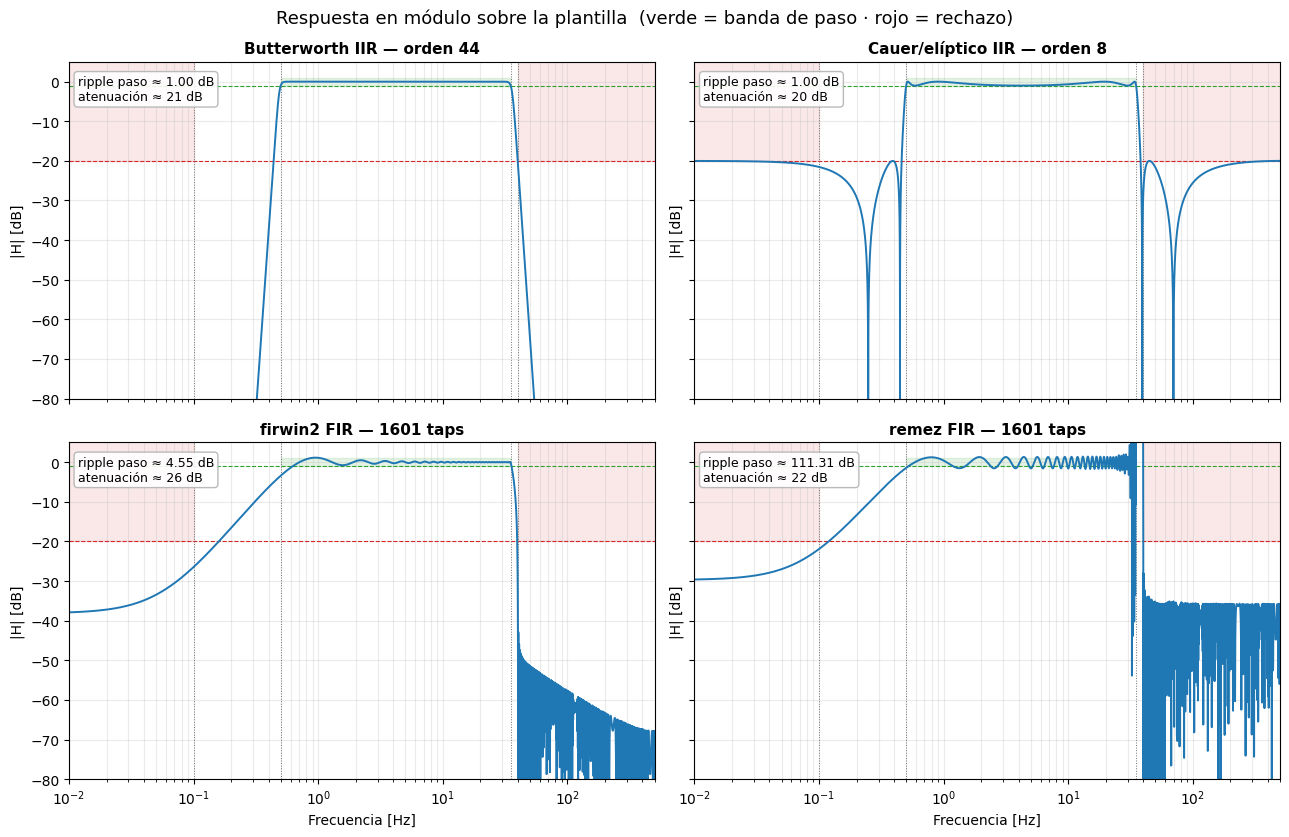

In [11]:
#%% c) Respuesta en módulo de cada filtro sobre la plantilla

# --- grilla de frecuencias: backbone2 log + densa en las hammingtransiciones ---
def grilla_w(ws1, wp1, wp2, ws2, fmin=1e-2, fmax=nyq_frec, n_log=4000, n_tr=15040):
    base  = np.logspace(np.log10(fmin), np.log10(fmax), n_log)
    tr_lo = np.linspace(0.7*ws1, 1.3*wp1, n_tr)   # transición baja
    tr_hi = np.linspace(0.9*wp2, 1.5*ws2, 5 * n_tr)   # transición alta
    w = np.unique(np.concatenate([base, tr_lo, tr_hi]))
    return w[(w > 0) & (w <= fmax)]

w = grilla_w(ws1, wp1, wp2, ws2)

def H_db(filtro, fir=False):
    ww, H = (sig.freqz(filtro, worN=w, fs=fs) if fir
             else sig.sosfreqz(filtro, worN=w, fs=fs))
    return ww, 20*np.log10(np.abs(H) + 1e-12)

def metricas(ww, mod):
    """ripple real en banda de paso y atenuación peor-caso en rechazo (dB)."""
    pb = (ww >= wp1) & (ww <= wp2)
    sb = (ww <= ws1) | (ww >= ws2)
    return mod[pb].max() - mod[pb].min(), -mod[sb].max()

fig, axs = plt.subplots(2, 2, figsize=(13, 8.5), sharex=True, sharey=True)
for ax, (nombre, f, fir) in zip(axs.flat, filtros):
    ww, mod = H_db(f, fir)
    rip, at = metricas(ww, mod)

    # plantilla como "muro" de tolerancia
    ax.fill_between([w.min(), ws1],  -atenuacion, 5, color='tab:red',   alpha=.10)
    ax.fill_between([ws2, nyq_frec], -atenuacion, 5, color='tab:red',   alpha=.10)
    ax.fill_between([wp1, wp2],      -ripple,     1, color='tab:green', alpha=.12)
    ax.axhline(-atenuacion, color='tab:red',   ls='--', lw=.8)
    ax.axhline(-ripple,     color='tab:green', ls='--', lw=.8)
    for e in (ws1, wp1, wp2, ws2):
        ax.axvline(e, color='0.45', ls=':', lw=.7)

    ax.plot(ww, mod, lw=1.4, color='tab:blue')
    ax.set_title(nombre, fontsize=11, fontweight='bold')
    ax.text(.015, .96, f'ripple paso ≈ {rip:.2f} dB\natenuación ≈ {at:.0f} dB',
            transform=ax.transAxes, fontsize=9, va='top', ha='left',
            bbox=dict(boxstyle='round', fc='white', ec='0.7', alpha=.9))
    ax.set_xscale('log'); ax.set_xlim(1e-2, nyq_frec); ax.set_ylim(-80, 5)
    ax.grid(True, which='both', alpha=.25); ax.set_ylabel('|H| [dB]')

for ax in axs[1]:
    ax.set_xlabel('Frecuencia [Hz]')
fig.suptitle('Respuesta en módulo sobre la plantilla  (verde = banda de paso · rojo = rechazo)',
             fontsize=13)
plt.tight_layout(); plt.show()